<a href="https://colab.research.google.com/github/RichardDoh/Flutter-Calculator-/blob/main/SignLanguageTranslation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

# Specify the path to your zipped dataset
zip_file_path = '/content/compressed_file.zip'
extract_folder = '/content/extracted_frames'

# Create a directory to extract the files
os.makedirs(extract_folder, exist_ok=True)

# Unzip the dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset unzipped successfully!")


Dataset unzipped successfully!


In [ ]:
!pip install rarfile

In [ ]:
import rarfile
import os

# Specify the path to your .rar dataset
rar_file_path = '/content/SIGNER2.rar'
extract_folder = '/content/extract'

# Create a directory to extract the files
os.makedirs(extract_folder, exist_ok=True)

# Unrar the dataset
with rarfile.RarFile(rar_file_path) as rf:
    rf.extractall(path=extract_folder)

print("Dataset unrarred successfully!")


Dataset unrarred successfully!


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [ ]:
import os

# Path to the folder in Google Colab
folder = '/content/extract/SIGNER2'  # Change this to your actual folder path

# List all files and directories in the specified folder
files = os.listdir(folder)

# Print the files and directories
for file in files:
    print(file)


DAD_S2.mp4
URINE_S2.mp4
DYSLEXIA_S2.mp4
DIRTY_S2.mp4
HEADLICE_S2.mp4
PARENT_S2.mp4
FEVER_S2.mp4
GLAUCOMA_S2.mp4
COUGH_S2.mp4
DISABILITY_S2.mp4
BORN_S2.mp4
AIRBORNE_S2.mp4
SEX_S2.mp4
CANCER_S2.mp4
AFTERBIRTH_S2.mp4
ADMITTED_S2.mp4
MUSCLE_S2.mp4
NERVOUS_S2.mp4
REPRODUCTIVE_S2.mp4
CONTRACEPTIVES_S2.mp4
DEVELOP_S2.mp4
DIZZINESS_S2.mp4
MENSTRUATION_S2.mp4
CONSTIPATION_I_S2.mp4
STILLBIRTH_S2.mp4
ABORTION_S2.mp4
BIRTH_S2.mp4
CURE_S2.mp4
DIARRHEA_S2.mp4
INFLAMMATION_S2.mp4
LEPROSY_S2.mp4
EBOLA_S2.mp4
CAESAREAN_S2.mp4
ASTHMA_S2.mp4
INFANT_S2.mp4
TEETHING_I_S2.mp4
DELIVERY_S2.mp4
HIV AIDS _II_S2.mp4
VISION_S2.mp4
DIABETES_S2.mp4
SUPRESSION_S2.mp4
DEAFNESS_S2.mp4
INFERTILITY_s2.mp4
HEADACHE_S2.mp4
ANAESTHESIA_S2.mp4
CARER_S2.mp4
COVID-19_S2.mp4
HYPERTENSION_S2.mp4
FRACTURE_S2.mp4
DEMENTIA_S2.mp4
CRYING_S2.mp4
FIBROID_S2.mp4
NURSING_S2.mp4
LABOUR_S2.mp4
CHILD_S2.mp4
CONSTIPATION_II_S2.mp4
COLD_S2.mp4
HEARTBURN_S2.mp4
TREATMENT_S2.mp4
HUNGER_S2.mp4
ATTENDANCE_S2.mp4
MOTHER_S2.mp4
FLU_S2.mp4
GROWTH_

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Path to the folder containing videos in Google Colab
video_folder_path = '/content/extract/SIGNER2'  # Change this to your actual folder path

# Path to the folder where extracted frames will be saved
output_base_path = '/content/extracted_frames'  # Change this if needed

# Create the base output folder if it doesn't exist
os.makedirs(output_base_path, exist_ok=True)

# List all video files in the folder with specified extensions
video_files = [f for f in os.listdir(video_folder_path) if f.endswith(('.mp4', '.avi', '.mov'))]

print("Video files found:")
for video_file in video_files:
    print(video_file)

# Function to extract frames from a video and save them in a specified folder
def extract_and_save_frames(video_path, output_folder):
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    video_capture = cv2.VideoCapture(video_path)

    if not video_capture.isOpened():
        print(f"Error: Could not open video {video_path}")
        return

    frame_count = 0

    while True:
        success, frame = video_capture.read()
        if not success:
            break

        # Save the current frame as an image
        frame_filename = os.path.join(output_folder, f"frame_{frame_count:04d}.jpg")
        cv2.imwrite(frame_filename, frame)  # Save frame as a .jpg file
        frame_count += 1

    video_capture.release()
    print(f"Extracted {frame_count} frames from {video_path} and saved to {output_folder}")

# Process each video and extract frames to a unique folder
for video_file in video_files:
    video_name = video_file.split('.')[0]  # Get video name without extension
    video_path = os.path.join(video_folder_path, video_file)

    # Create a folder for the extracted frames for this video
    video_output_folder = os.path.join(output_base_path, video_name)

    # Extract and save frames to the folder
    extract_and_save_frames(video_path, video_output_folder)


Video files found:
DAD_S2.mp4
URINE_S2.mp4
DYSLEXIA_S2.mp4
DIRTY_S2.mp4
HEADLICE_S2.mp4
PARENT_S2.mp4
FEVER_S2.mp4
GLAUCOMA_S2.mp4
COUGH_S2.mp4
DISABILITY_S2.mp4
BORN_S2.mp4
AIRBORNE_S2.mp4
SEX_S2.mp4
CANCER_S2.mp4
AFTERBIRTH_S2.mp4
ADMITTED_S2.mp4
MUSCLE_S2.mp4
NERVOUS_S2.mp4
REPRODUCTIVE_S2.mp4
CONTRACEPTIVES_S2.mp4
DEVELOP_S2.mp4
DIZZINESS_S2.mp4
MENSTRUATION_S2.mp4
CONSTIPATION_I_S2.mp4
STILLBIRTH_S2.mp4
ABORTION_S2.mp4
BIRTH_S2.mp4
CURE_S2.mp4
DIARRHEA_S2.mp4
INFLAMMATION_S2.mp4
LEPROSY_S2.mp4
EBOLA_S2.mp4
CAESAREAN_S2.mp4
ASTHMA_S2.mp4
INFANT_S2.mp4
TEETHING_I_S2.mp4
DELIVERY_S2.mp4
HIV AIDS _II_S2.mp4
VISION_S2.mp4
DIABETES_S2.mp4
SUPRESSION_S2.mp4
DEAFNESS_S2.mp4
INFERTILITY_s2.mp4
HEADACHE_S2.mp4
ANAESTHESIA_S2.mp4
CARER_S2.mp4
COVID-19_S2.mp4
HYPERTENSION_S2.mp4
FRACTURE_S2.mp4
DEMENTIA_S2.mp4
CRYING_S2.mp4
FIBROID_S2.mp4
NURSING_S2.mp4
LABOUR_S2.mp4
CHILD_S2.mp4
CONSTIPATION_II_S2.mp4
COLD_S2.mp4
HEARTBURN_S2.mp4
TREATMENT_S2.mp4
HUNGER_S2.mp4
ATTENDANCE_S2.mp4
MOTHER_S2.mp4

In [ ]:
import os
import shutil

# Step 1: Compress the folder into a .zip file
def create_zip(folder_path, output_zip_path):
    # Use shutil to compress the folder into a .zip file
    shutil.make_archive(output_zip_path.replace('.zip', ''), 'zip', folder_path)
    print(f"Folder compressed to {output_zip_path}")

# Path where Google Drive is mounted in Colab
drive_mount_path = '/content/drive/My Drive/'

# Specify your folder path to compress (in Colab environment)
folder_to_compress = '/content/extracted_frames'  # Change this to your folder path
output_zip_file = drive_mount_path + 'compressed_file.zip'  # Output to Google Drive

# Step 2: Compress and save to Google Drive
create_zip(folder_to_compress, output_zip_file)


Folder compressed to /content/drive/My Drive/compressed_file.zip


In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 4.25.5 which is incompatible.
tensorflow-metadata 1.15.0 requires protobuf<4.21,>=3.20.3; python_version < "3.11", but you have protobuf 4.25.5 which is incompatible.


Processing word: COLD_S2
Nose coordinates for frame_0042.jpg: (600.9885406494141, 246.89347743988037)


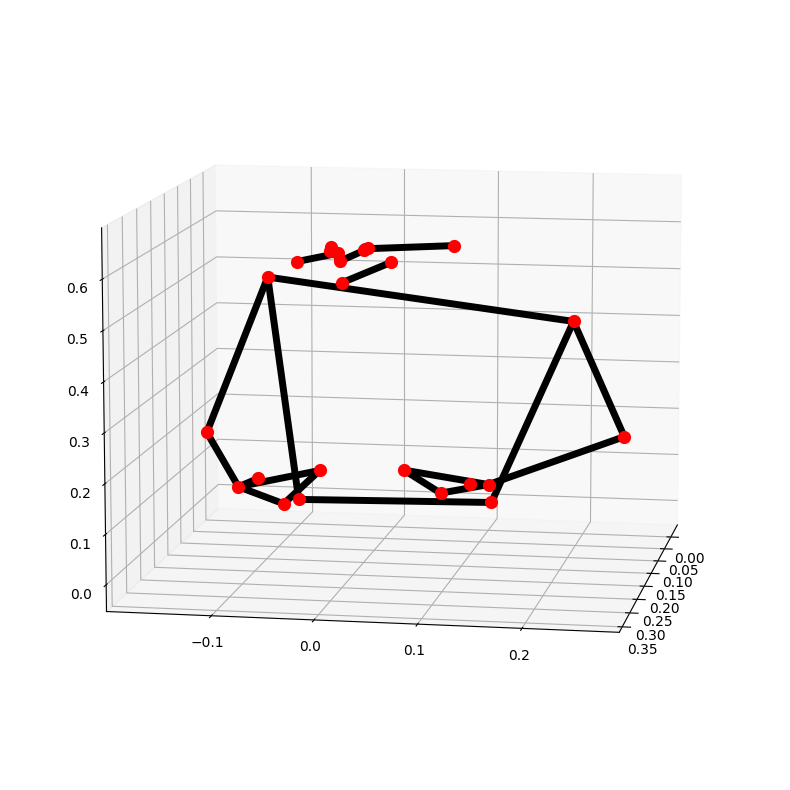

Nose coordinates for frame_0069.jpg: (581.1838531494141, 254.32225227355957)


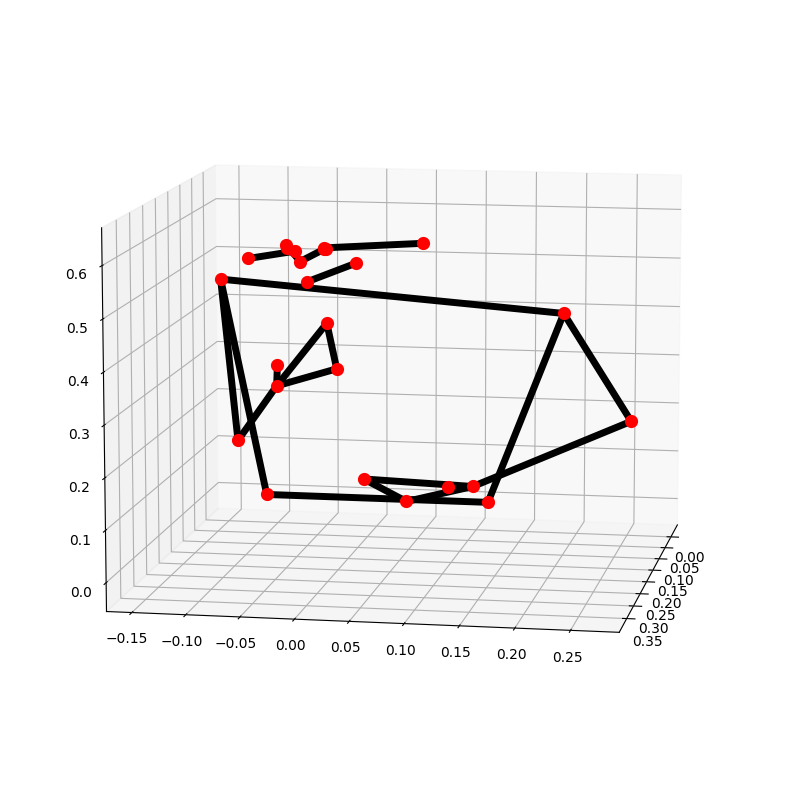

Nose coordinates for frame_0138.jpg: (592.9067230224609, 250.55771827697754)


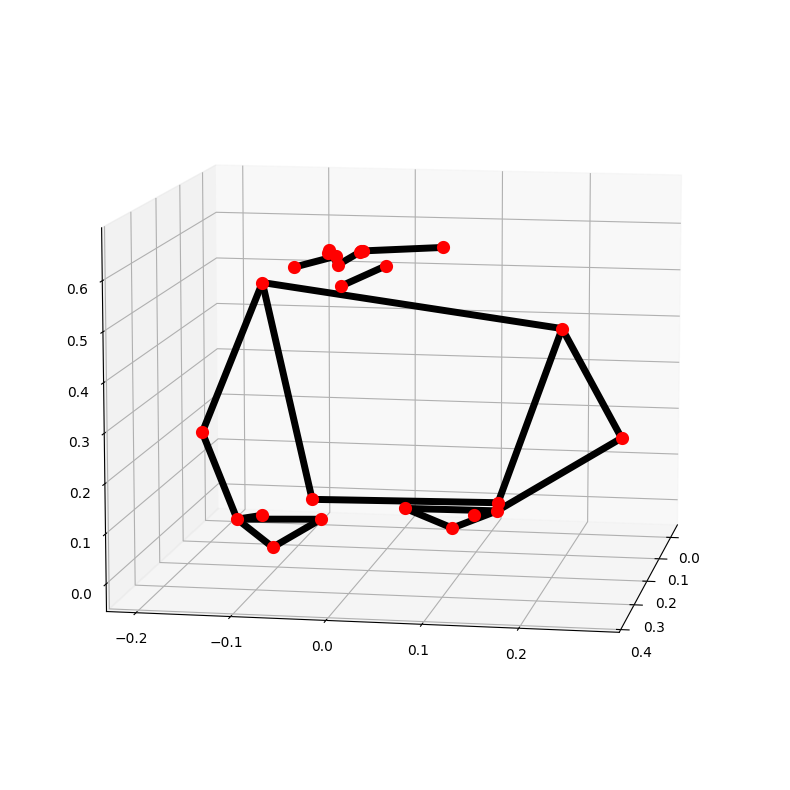

Nose coordinates for frame_0007.jpg: (596.786994934082, 246.19404315948486)


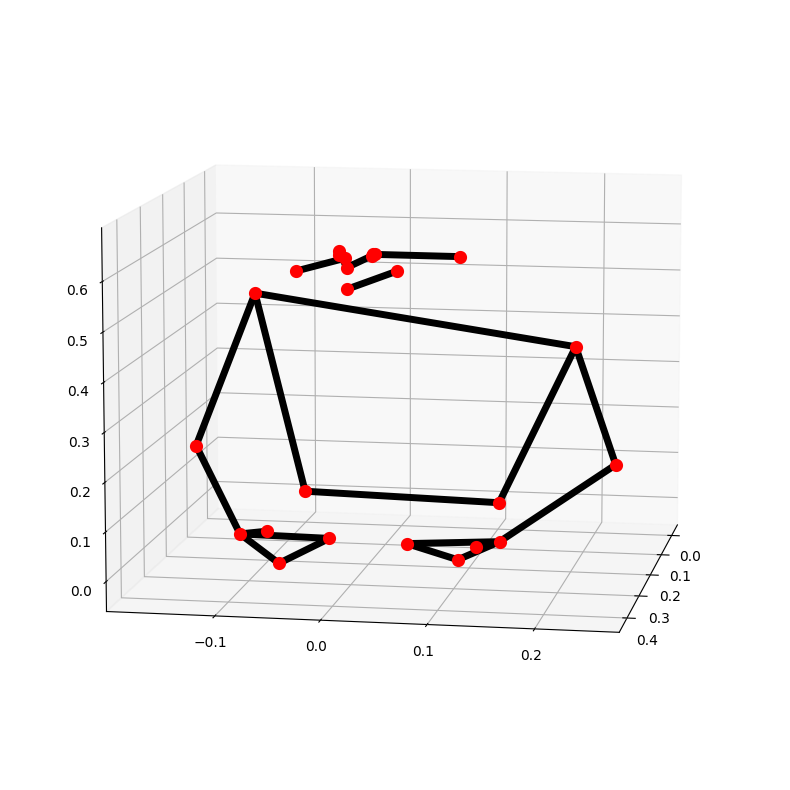

Nose coordinates for frame_0036.jpg: (601.2520217895508, 246.4041566848755)


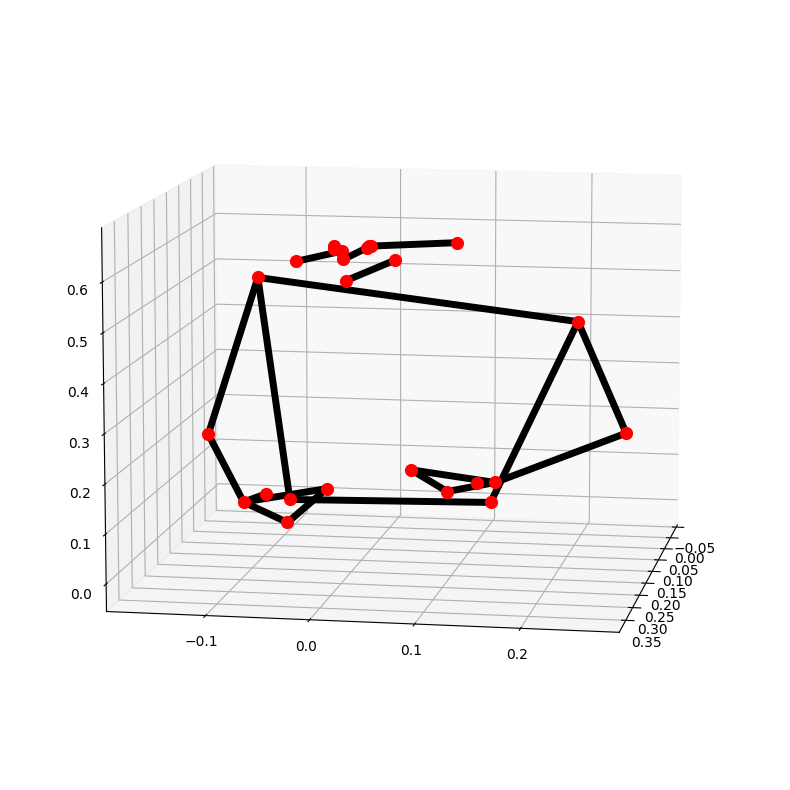

Nose coordinates for frame_0023.jpg: (601.7183685302734, 247.95631885528564)


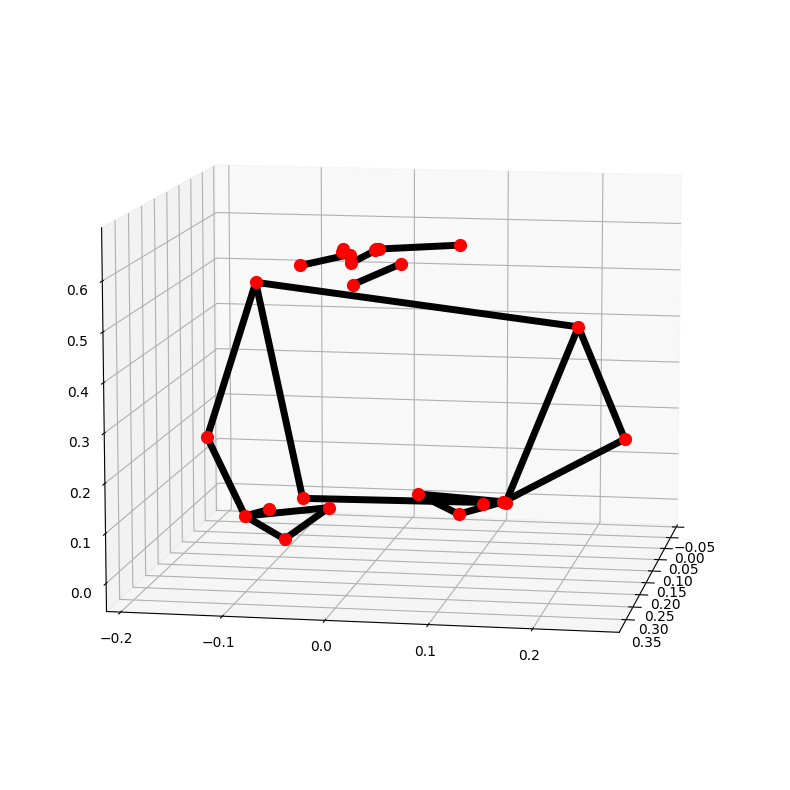

Nose coordinates for frame_0114.jpg: (577.5365447998047, 246.98205471038818)


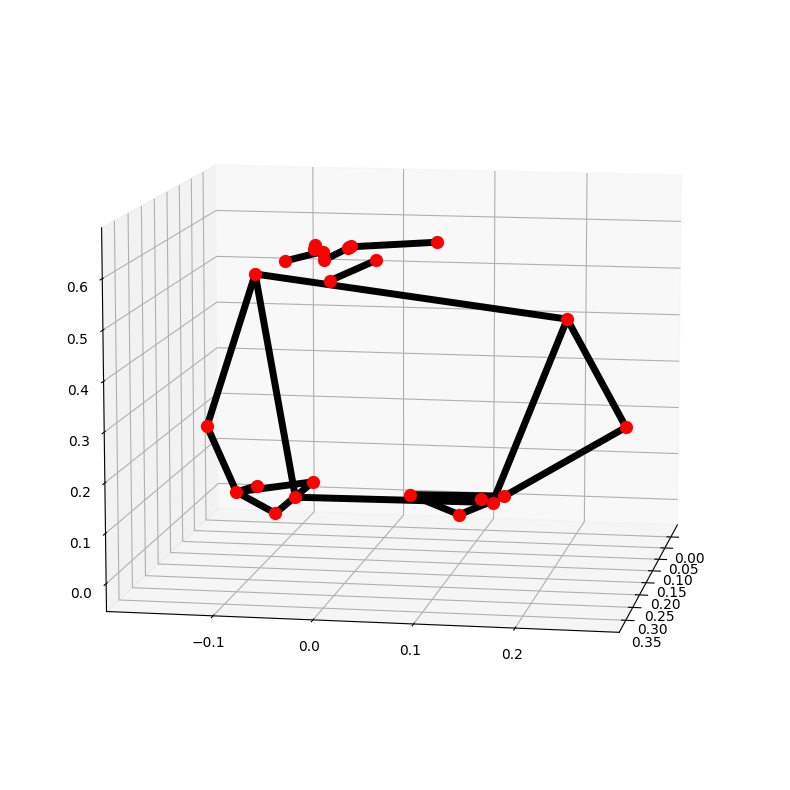

Nose coordinates for frame_0021.jpg: (599.4454193115234, 248.1578493118286)


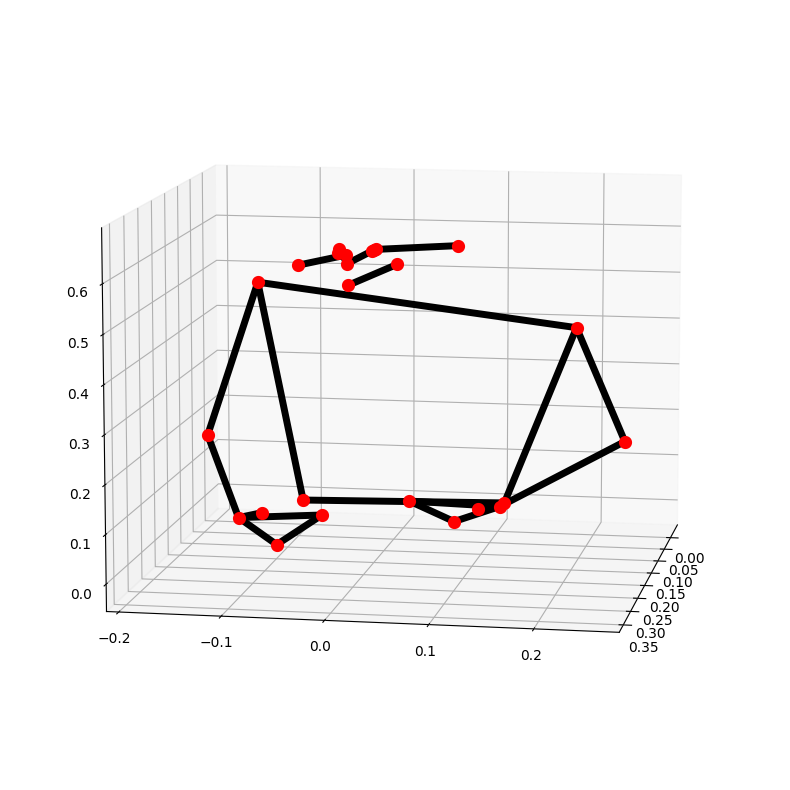

Nose coordinates for frame_0102.jpg: (569.841423034668, 254.27165508270264)


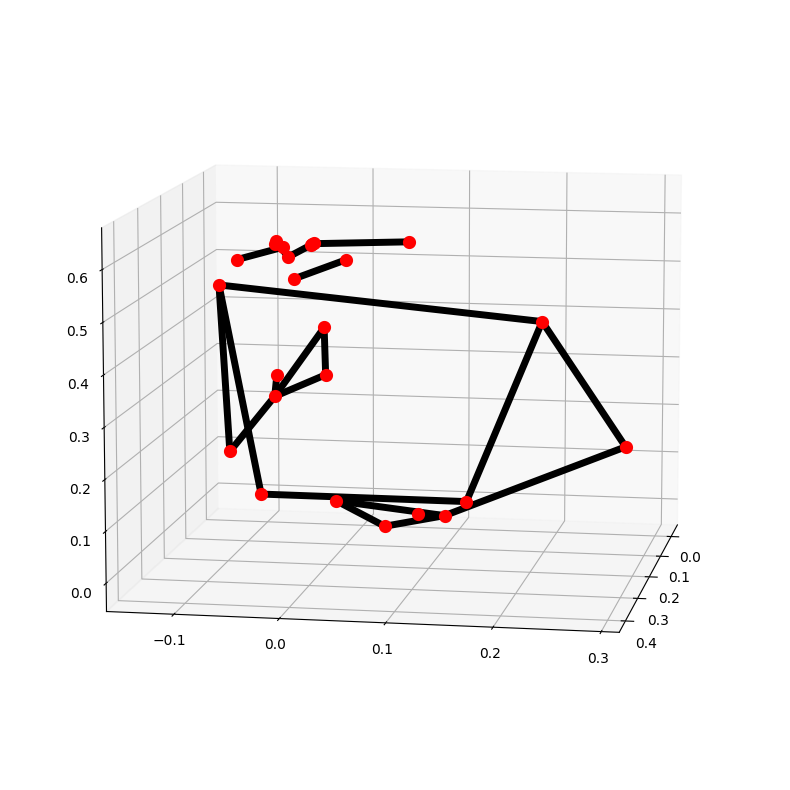

Nose coordinates for frame_0032.jpg: (602.5160598754883, 247.15530395507812)


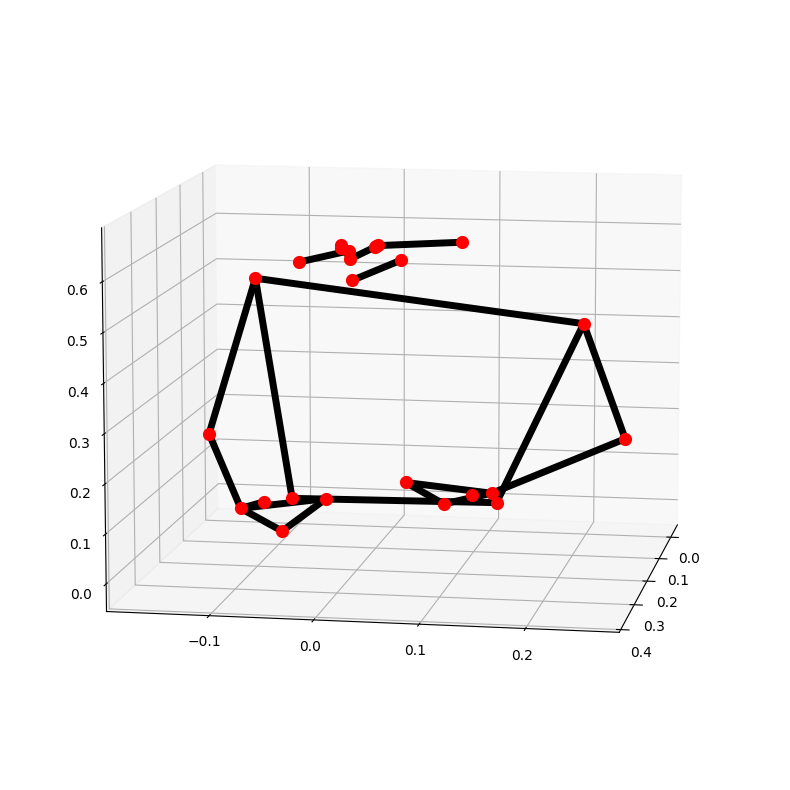

Nose coordinates for frame_0031.jpg: (602.0902633666992, 246.90858364105225)


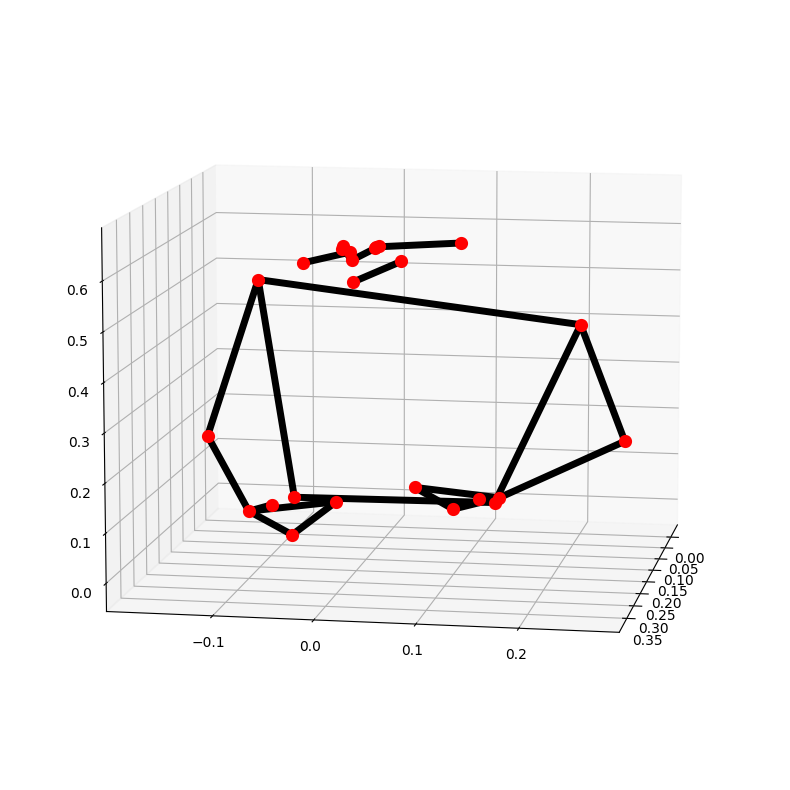

Nose coordinates for frame_0135.jpg: (591.8640899658203, 250.85434913635254)


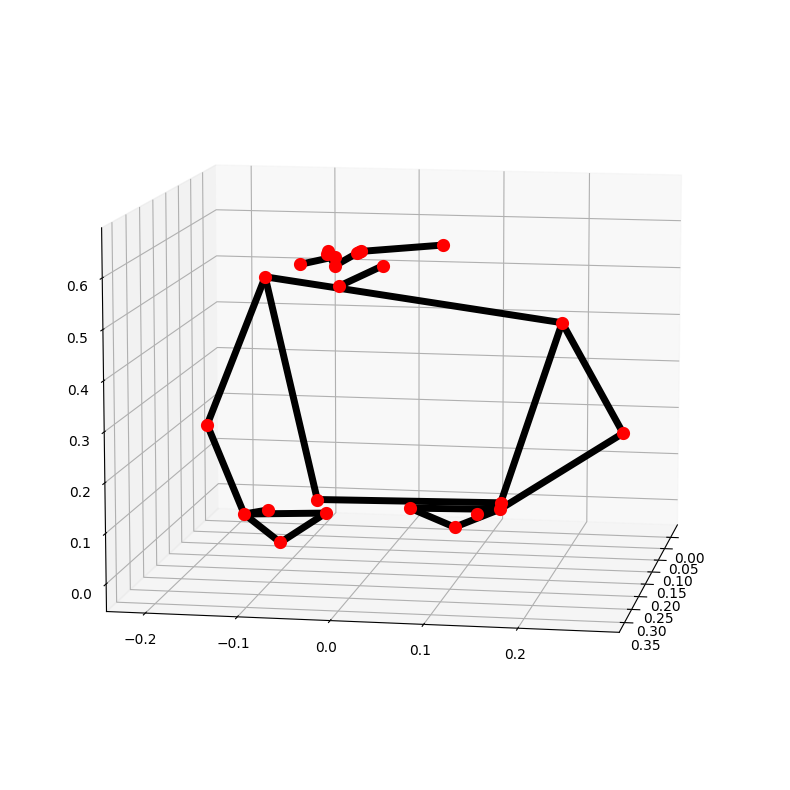

Nose coordinates for frame_0071.jpg: (579.4304656982422, 254.0170383453369)


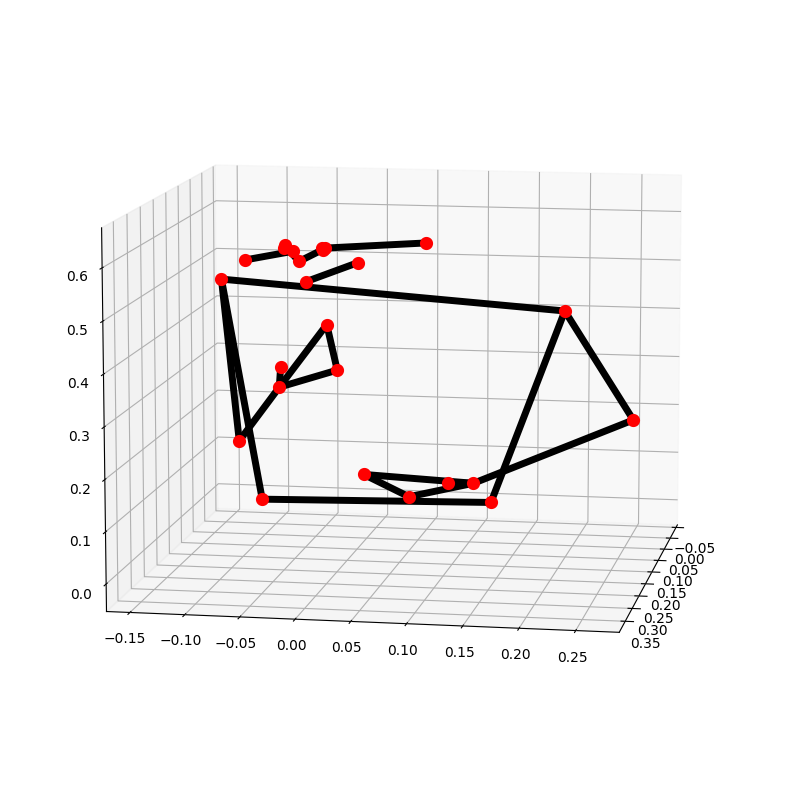

Nose coordinates for frame_0056.jpg: (586.7317962646484, 250.81812858581543)


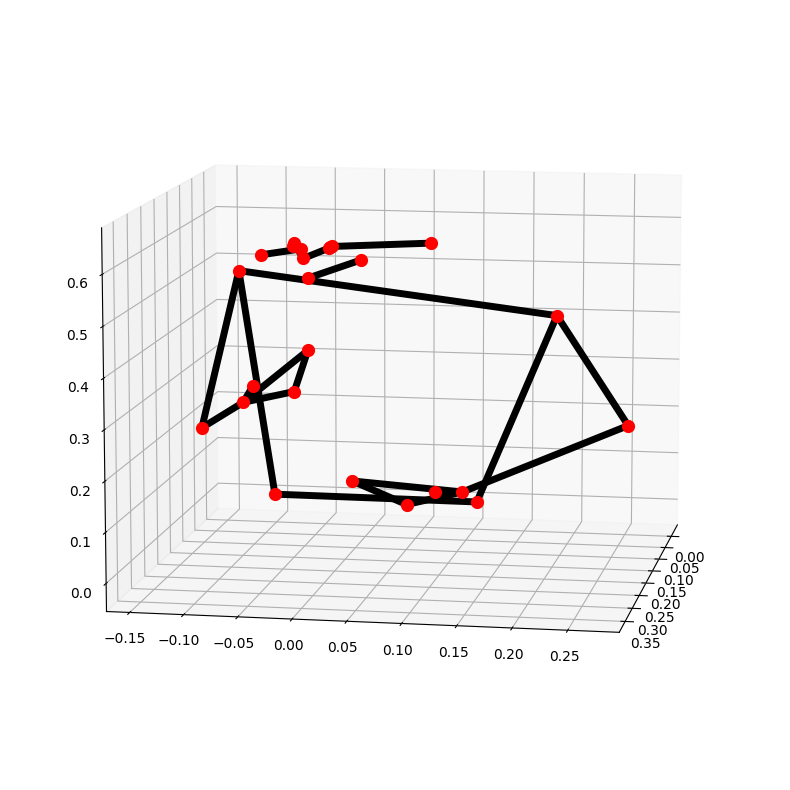

Nose coordinates for frame_0000.jpg: (593.926887512207, 246.95162773132324)


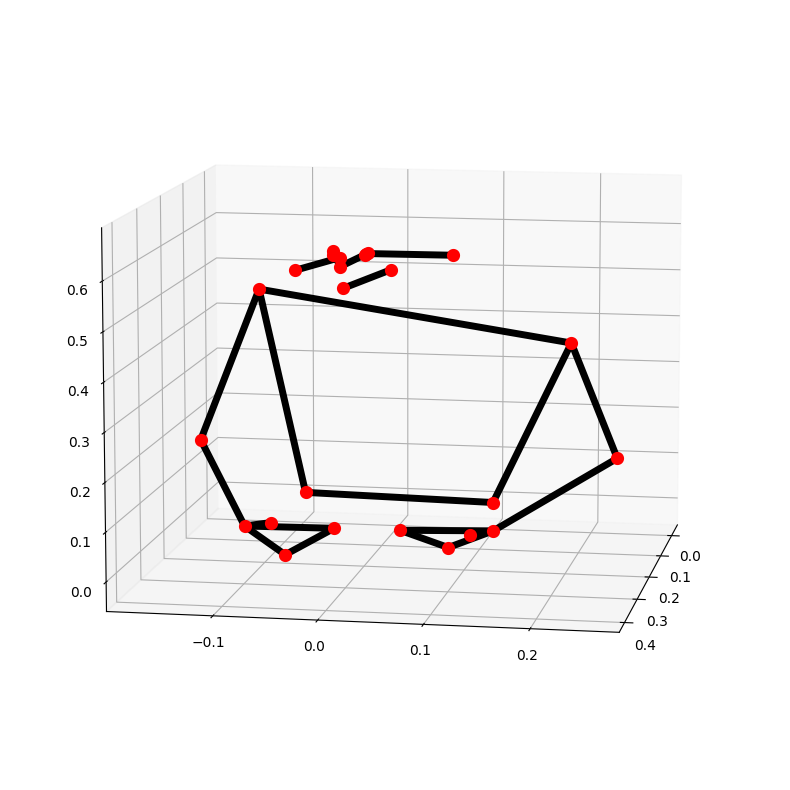

Nose coordinates for frame_0065.jpg: (580.986213684082, 254.11222457885742)


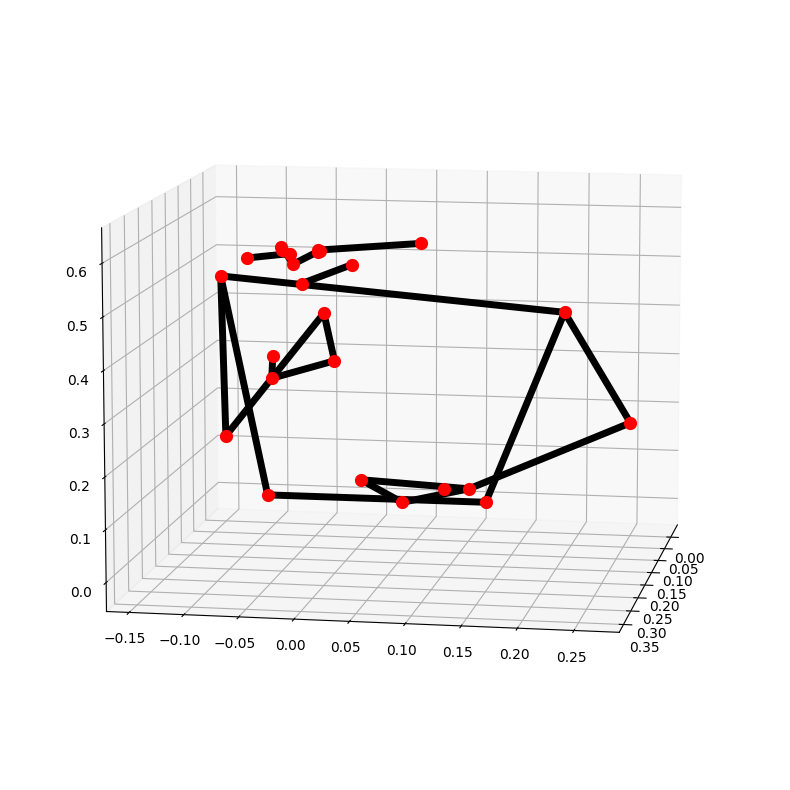

Nose coordinates for frame_0075.jpg: (577.5596237182617, 255.21630764007568)


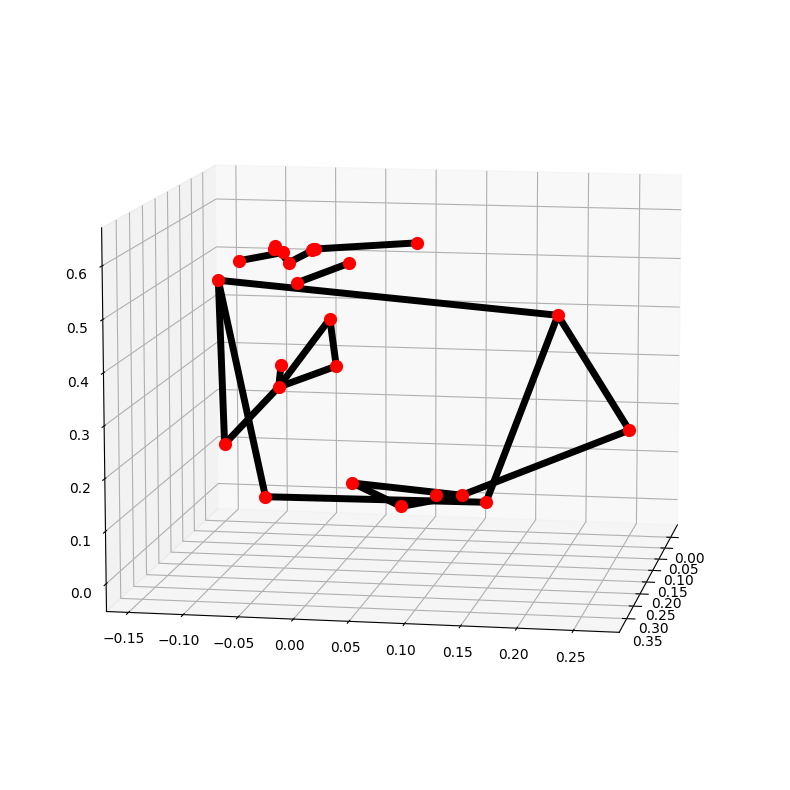

Nose coordinates for frame_0037.jpg: (602.4048614501953, 244.57368850708008)


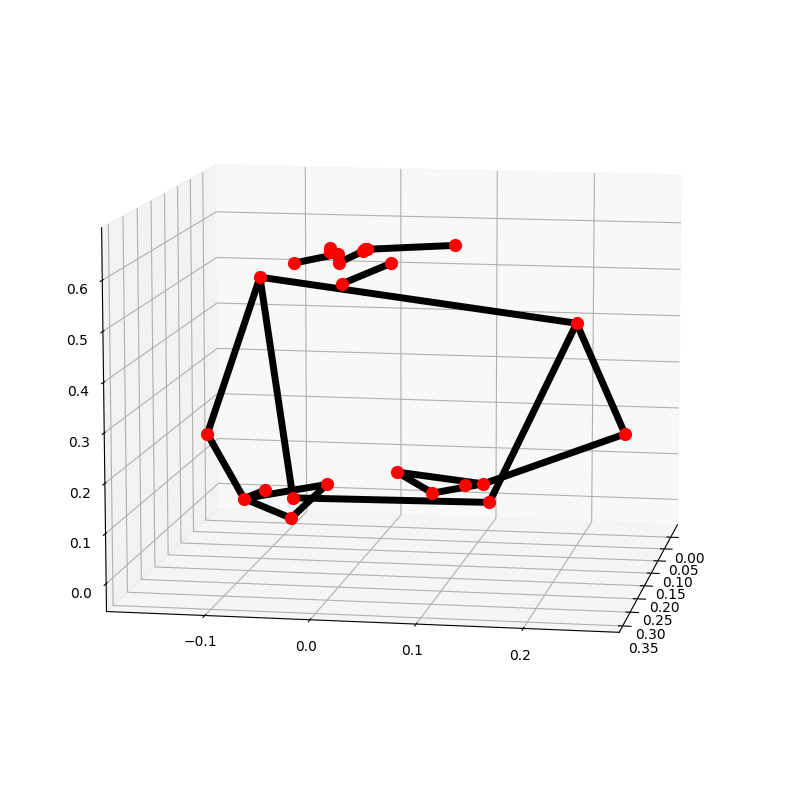

Nose coordinates for frame_0047.jpg: (597.7005767822266, 245.27711391448975)


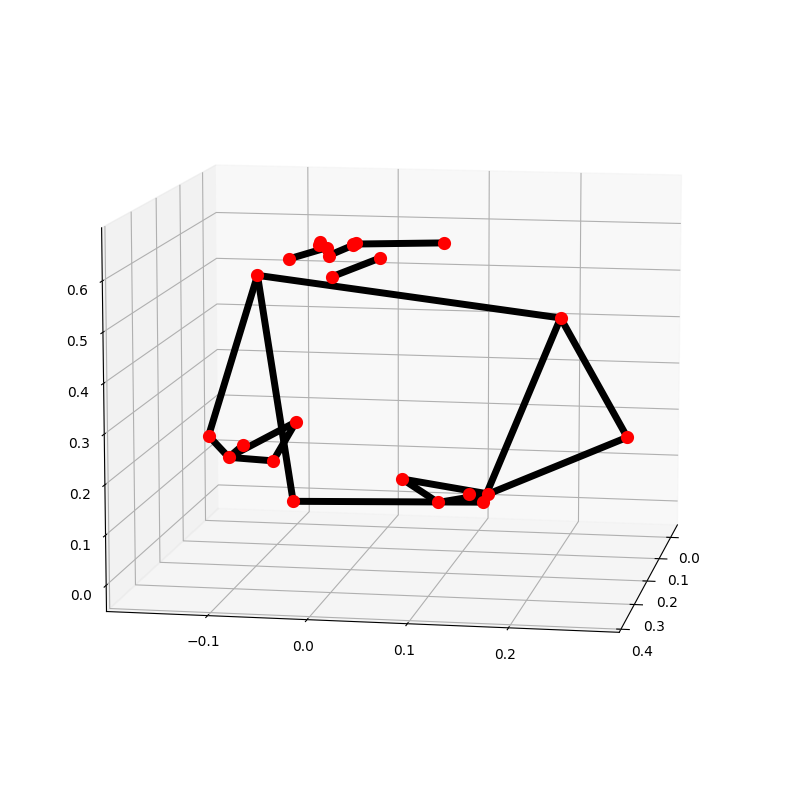

Nose coordinates for frame_0055.jpg: (588.0961990356445, 247.5465202331543)


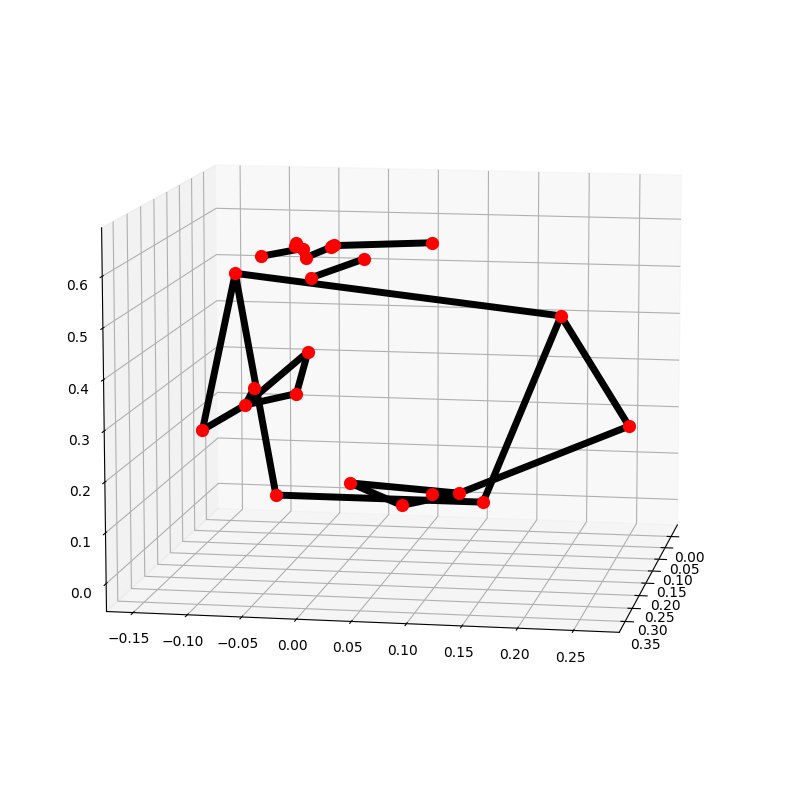

Nose coordinates for frame_0082.jpg: (572.2957611083984, 255.25536060333252)


KeyboardInterrupt: 

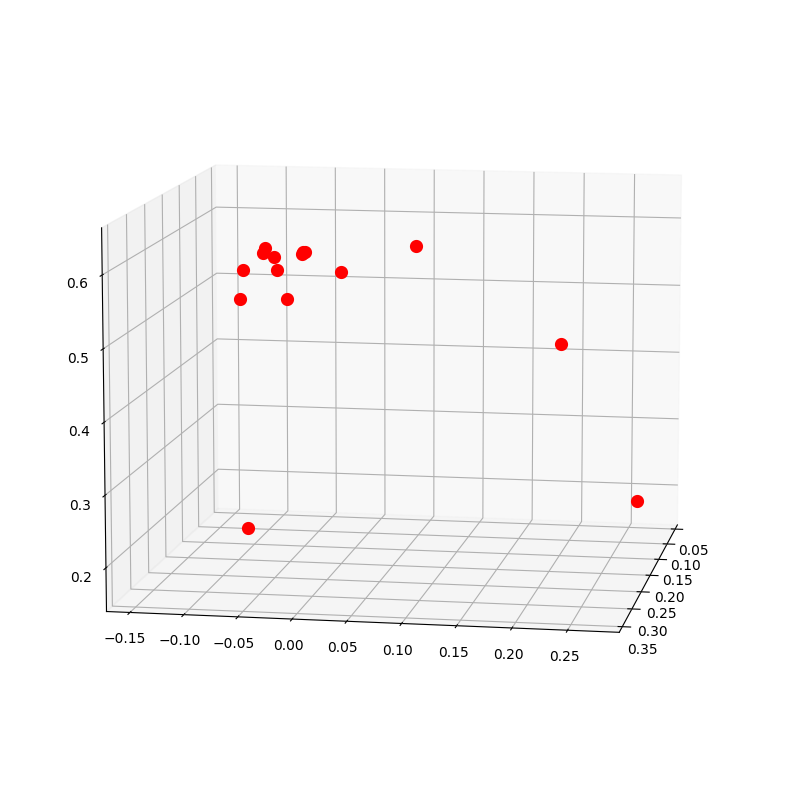

In [ ]:
import cv2
import mediapipe as mp
import os
import numpy as np

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_holistic = mp.solutions.holistic

# Path to the folder containing word folders
DATASET_PATH = '/content/extracted_frames'

# Path to save the annotated images
OUTPUT_PATH = '/content/annotated_files'

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

BG_COLOR = (192, 192, 192)  # Background color for segmentation

with mp_holistic.Holistic(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=True,
    refine_face_landmarks=True) as holistic:

    # Iterate through each word folder
    for word_folder in os.listdir(DATASET_PATH):
        word_path = os.path.join(DATASET_PATH, word_folder)

        if os.path.isdir(word_path):  # Check if it's a directory (word folder)
            print(f"Processing word: {word_folder}")

            # Create a subfolder for annotated images
            output_word_path = os.path.join(OUTPUT_PATH, word_folder)
            os.makedirs(output_word_path, exist_ok=True)

            # Iterate through each frame (image) in the word folder
            for idx, image_file in enumerate(os.listdir(word_path)):
                image_path = os.path.join(word_path, image_file)

                if image_path.endswith(('.png', '.jpg', '.jpeg')):  # Only process image files
                    image = cv2.imread(image_path)
                    if image is None:
                        print(f"Could not read image {image_path}. Skipping.")
                        continue

                    image_height, image_width, _ = image.shape
                    # Convert the BGR image to RGB for processing
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

                    # Annotate nose coordinates if pose landmarks are found
                    if results.pose_landmarks:
                        nose_x = results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x * image_width
                        nose_y = results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y * image_height
                        print(f'Nose coordinates for {image_file}: ({nose_x}, {nose_y})')

                    annotated_image = image.copy()

                    # Draw segmentation on the image if available
                    if results.segmentation_mask is not None:
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, bg_image)

                    # Draw face, pose, and hand landmarks
                    if results.face_landmarks:
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style())

                    if results.pose_landmarks:
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style())

                    # Save the annotated image in the corresponding word folder
                    save_path = os.path.join(output_word_path, f'annotated_{idx}.png')
                    cv2.imwrite(save_path, annotated_image)

                    # Optionally plot pose landmarks in 3D (useful for debugging)
                    if results.pose_world_landmarks:
                        mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_holistic.POSE_CONNECTIONS)
